###**Preproccessing**

In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import re, html     # Regular expressions & HTML unescaping
import string      # String constants
import seaborn as sb
import matplotlib.pyplot as plt

In [1]:
# Text Normalization & NLP Libraries
import nltk
from nltk.tokenize import word_tokenize, TweetTokenizer     # Text normalization: Tokenization
from nltk import word_tokenize, pos_tag     # Part-of-Speech tagging
from nltk.stem import WordNetLemmatizer     # Text normalization: Lemmatization
from nltk.corpus import wordnet
from nltk.corpus import stopwords     # Remove stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer     # TF-IDF feature extraction

# Download Required NLTK Resources
nltk.download("punkt")     # Tokenizer models
nltk.download("punkt_tab")     # Additional tokenizer tables
nltk.download('stopwords')     # Stopword list
nltk.download('averaged_perceptron_tagger_eng')     # POS tagger
nltk.download('wordnet')     # Lemmatization resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [6]:
#Machine Learning Libraries
from sklearn.model_selection import train_test_split     # Splits data into train and test sets
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB     # Multinomial Naive Bayes

# Evaluation Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [ ]:
train_path = "/content/train.csv"
df = pd.read_csv(train_path)   # Load the dataset
df.head()     # observe 5 first rows

,id,tweet,label
0,86426,@USER She should ask a few native Americans wh...,UNT
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN
2,16820,Amazon is investigating Chinese employees who ...,NOT
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT


<Axes: xlabel='label', ylabel='count'>

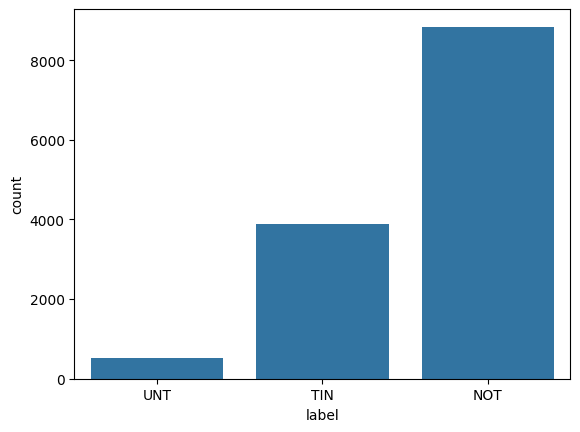

In [ ]:
# Summarise class details
sb.countplot(x=df['label'])

In [ ]:
print("Shape:", df.shape)
print("\nLabel counts:\n", df["label"].value_counts())

Shape: (13240, 3)

Label counts:
 label
NOT    8840
TIN    3876
UNT     524
Name: count, dtype: int64


In [ ]:
df.dropna(inplace=True)
print(f'Number of entries: {len(df)}')

Number of entries: 13240


In [ ]:
# Regex normalization
def normalize_profanity(tweet):
    tweet = re.sub(r"\bbull\s*sh\W*t\b", "bullshit", tweet, flags=re.I)
    tweet = re.sub(r"\bsh\W*t\b", "shit", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*ing\b", "fucking", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*s\b", "fucks", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\b", "fuck", tweet, flags=re.I)
    tweet = re.sub(r"\bd\W*mbasses\b", "dumbasses", tweet, flags=re.I)
    tweet = re.sub(r"\bc\W*ck\b", "cock", tweet, flags=re.I)
    return tweet

In [ ]:
# convert text to tokens
tokenizer = TweetTokenizer(preserve_case=False,
                    strip_handles=True,
                    reduce_len=True
)
for i in range(5):
    tweet = df["tweet"].iloc[i]
    tokens = tokenizer.tokenize(tweet)
    print("Original:", tweet)
    print("Tokens:", tokens)
    print("-" * 50)

Original: @USER She should ask a few native Americans what their take on this is.
Tokens: ['she', 'should', 'ask', 'a', 'few', 'native', 'americans', 'what', 'their', 'take', 'on', 'this', 'is', '.']
--------------------------------------------------
Original: @USER @USER Go home you’re drunk!!! @USER #MAGA #Trump2020 👊🇺🇸👊 URL
Tokens: ['go', 'home', 'you', '’', 're', 'drunk', '!', '!', '!', '#maga', '#trump2020', '👊', '🇺🇸', '👊', 'url']
--------------------------------------------------
Original: Amazon is investigating Chinese employees who are selling internal data to third-party sellers looking for an edge in the competitive marketplace. URL #Amazon #MAGA #KAG #CHINA #TCOT
Tokens: ['amazon', 'is', 'investigating', 'chinese', 'employees', 'who', 'are', 'selling', 'internal', 'data', 'to', 'third-party', 'sellers', 'looking', 'for', 'an', 'edge', 'in', 'the', 'competitive', 'marketplace', '.', 'url', '#amazon', '#maga', '#kag', '#china', '#tcot']
---------------------------------------

In [ ]:
# Merge to tokens back into sentences by adding a space between two tokens.
joined_tokens_list = []
for tweet in df["tweet"]:
    tokens = tokenizer.tokenize(tweet)
    joined_tokens = " ".join(tokens)
    joined_tokens_list.append(joined_tokens)

# add new column to data frame
df["tokenized_tweet"] = joined_tokens_list
df.head()

,id,tweet,label,tokenized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to..."
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...


In [ ]:
# Apply POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [ ]:
# Lemmatized with WordNet to reduce inflected forms to their base form,
wnl = WordNetLemmatizer()
df["lemmatized_tweet"] = df["tokenized_tweet"].apply(
    lambda tweet_string: " ".join(
        wnl.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in nltk.pos_tag(nltk.word_tokenize(tweet_string))
    )
)
df.head()

,id,tweet,label,tokenized_tweet,lemmatized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...,she should ask a few native american what thei...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...,go home you ’ re drunk ! ! ! # maga # trump202...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...,amazon be investigate chinese employee who be ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to...",someone should'vetaken `` this piece of shit t...
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...,obama want liberal & illegals to move into red...


In [ ]:
# get English stopwords
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
# Define features and labels
X_tweet = df['tweet']
X_tokenized = df['tokenized_tweet']
X_lemmatized = df['lemmatized_tweet']
y = df['label']

In [ ]:
# Train / test split
(X_tweet_train, X_tweet_val,
 X_tokenized_train, X_tokenized_val,
 X_lemmatized_train, X_lemmatized_val,
 y_train, y_val) = train_test_split(X_tweet, X_tokenized, X_lemmatized, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# Sanity check
print("Tweet:", len(X_tweet_train),",", len(X_tweet_val))
print("Tokenized:", len(X_tokenized_train),",", len(X_tokenized_val))
print("Lemmatized:", len(X_lemmatized_train),",", len(X_lemmatized_val))
print("Labels:", len(y_train),",", len(y_val))

Tweet: 9268 , 3972
Tokenized: 9268 , 3972
Lemmatized: 9268 , 3972
Labels: 9268 , 3972


In [ ]:
# Evaluation function
def evaluate(actuals, predictions, labels):

    # 1) Accuracy
    accuracy = metrics.accuracy_score(actuals, predictions)
    print(f"Accuracy: {accuracy:.4f}")

    # 2) Precision, Recall, F1 (macro)
    precision = metrics.precision_score(actuals, predictions, average="macro", zero_division=0)
    recall = metrics.recall_score(actuals, predictions, average="macro", zero_division=0)
    f1 = metrics.f1_score(actuals, predictions, average="macro", zero_division=0)

    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")

    # 3) Confusion Matrix
    cm = metrics.confusion_matrix(actuals, predictions, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    # return values
    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm
    }

###**MultinomialNB**

In [ ]:
# Train a MultinomialNB and predict on validation data.
def get_naive_predictions(X_train, X_val, y_train, y_val):

    # build model
    classifier = MultinomialNB()
    classifier.fit(X_train, y_train)

    # make predictions on validation data
    y_pred = classifier.predict(X_val)

    # evaluation
    evaluate(y_val, y_pred, labels=["NOT", "TIN", "UNT"])

    return classifier

###**Models**

Accuracy: 0.7286
Precision (macro): 0.6205
Recall (macro):    0.4433
F1-score (macro):  0.4439


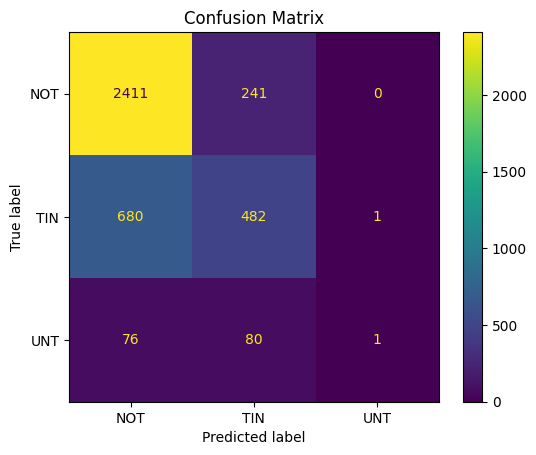

In [ ]:
# Model 1 - ngram_range=(1,1)
vectorizer = CountVectorizer(ngram_range=(1,1), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m1 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7082
Precision (macro): 0.4572
Recall (macro):    0.3924
F1-score (macro):  0.3791


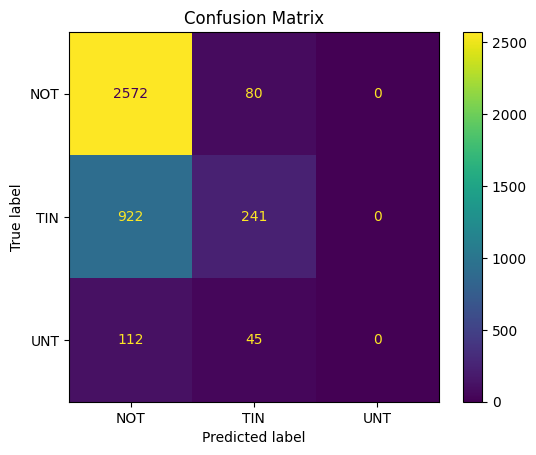

In [ ]:
# Model 1 - ngram_range=(1,2)
vectorizer = CountVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m11 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6808
Precision (macro): 0.4066
Recall (macro):    0.3777
F1-score (macro):  0.3637


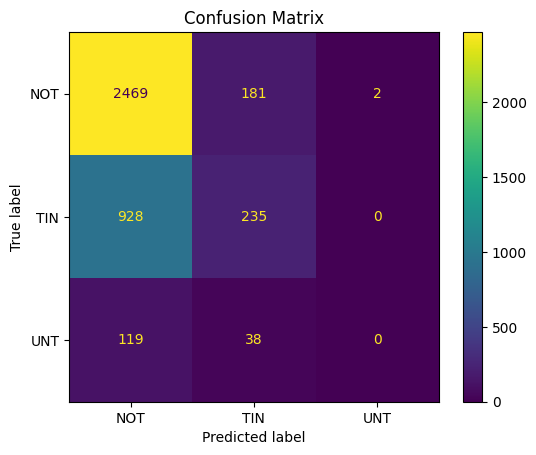

In [ ]:
# Model 1 - ngram_range=(2,2)
vectorizer = CountVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m12 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6946
Precision (macro): 0.4455
Recall (macro):    0.3740
F1-score (macro):  0.3505


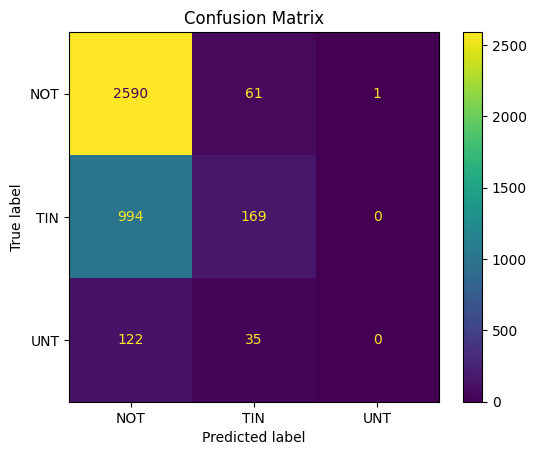

In [ ]:
# Model 1 - ngram_range=(1,3)
vectorizer = CountVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m13 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6523
Precision (macro): 0.3681
Recall (macro):    0.3587
F1-score (macro):  0.3422


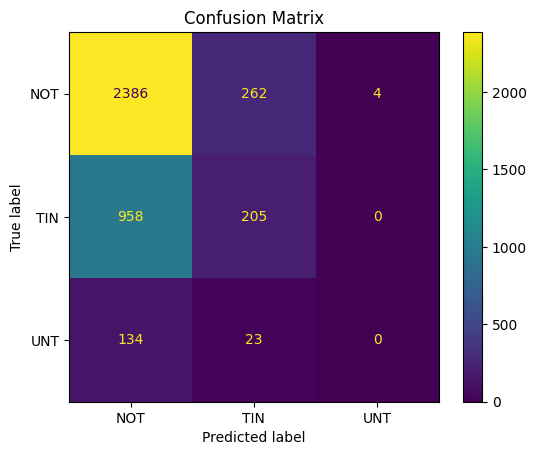

In [ ]:
# Model 1 - ngram_range=(3,3)
vectorizer = CountVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m14 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6815
Precision (macro): 0.4517
Recall (macro):    0.3509
F1-score (macro):  0.3047


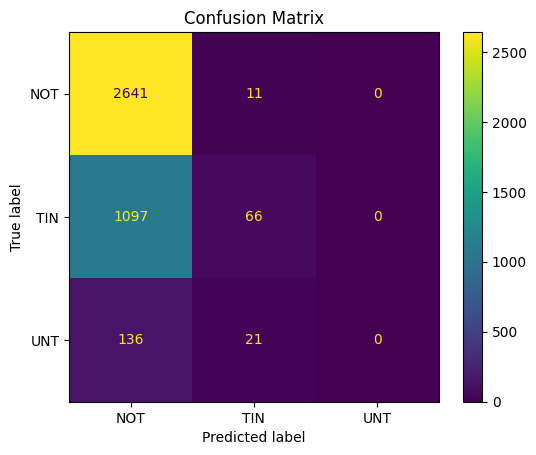

In [ ]:
# Model 2 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m2 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6715
Precision (macro): 0.4382
Recall (macro):    0.3381
F1-score (macro):  0.2778


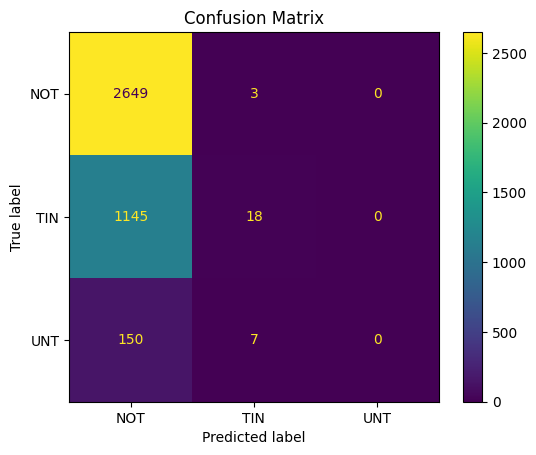

In [ ]:
# Model 2 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,2))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m21 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6715
Precision (macro): 0.4460
Recall (macro):    0.3381
F1-score (macro):  0.2778


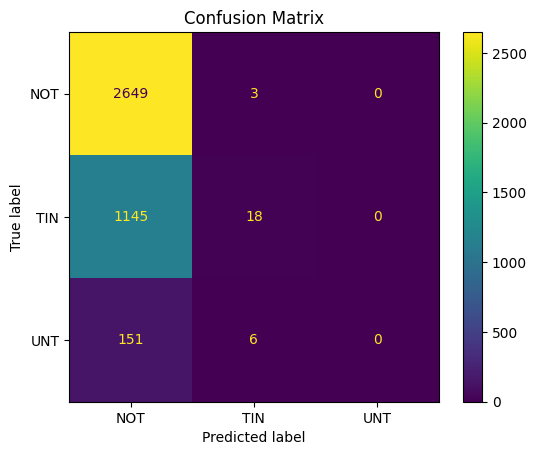

In [ ]:
# Model 2 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(2,2))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m22 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6712
Precision (macro): 0.4504
Recall (macro):    0.3378
F1-score (macro):  0.2772


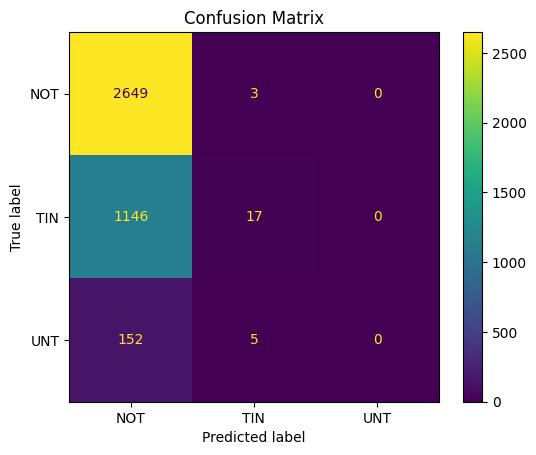

In [ ]:
# Model 2 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,3))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m23 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6694
Precision (macro): 0.4233
Recall (macro):    0.3361
F1-score (macro):  0.2740


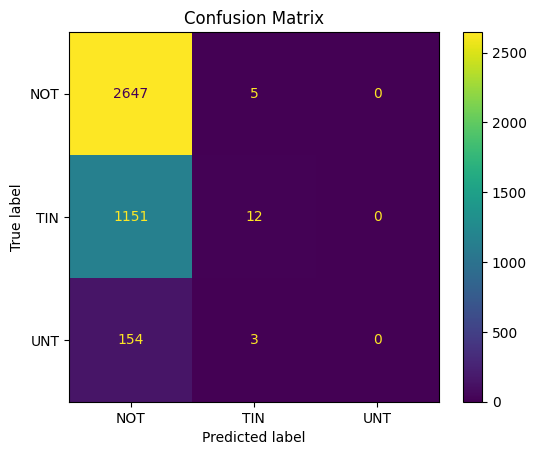

In [ ]:
# Model 2 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(3,3))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m24 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6843
Precision (macro): 0.4533
Recall (macro):    0.3543
F1-score (macro):  0.3115


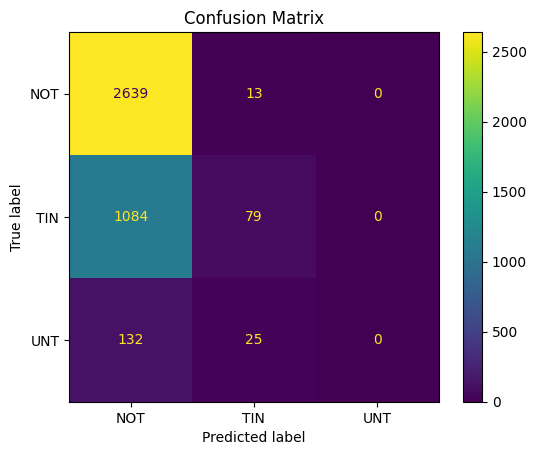

In [ ]:
# Model 3 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m3 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6735
Precision (macro): 0.4293
Recall (macro):    0.3406
F1-score (macro):  0.2832


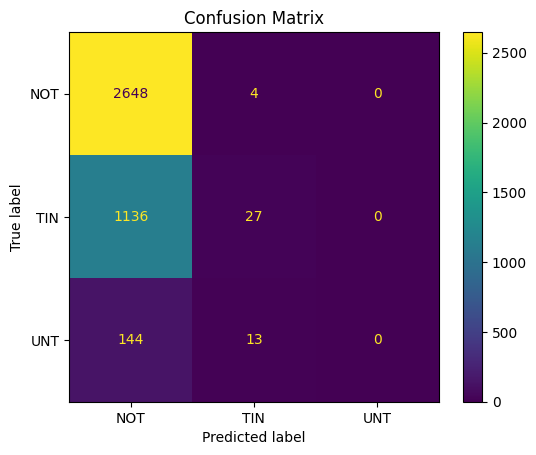

In [ ]:
# Model 3 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,2))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m31 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6704
Precision (macro): 0.4004
Recall (macro):    0.3376
F1-score (macro):  0.2776


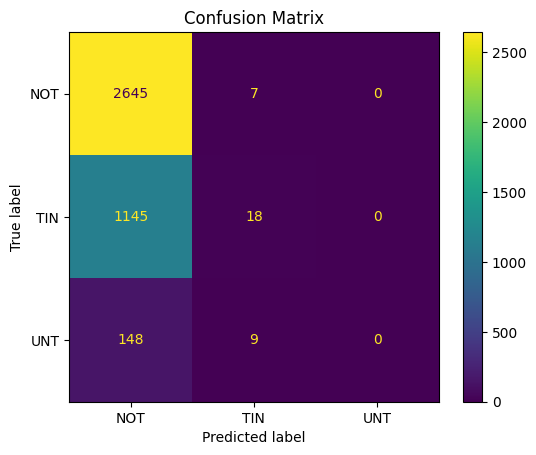

In [ ]:
# Model 3 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(2,2))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m32 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6717
Precision (macro): 0.4261
Recall (macro):    0.3386
F1-score (macro):  0.2790


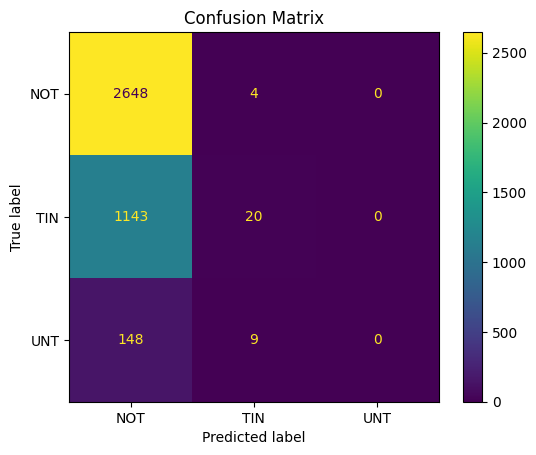

In [ ]:
# Model 3 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,3))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m33 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6682
Precision (macro): 0.3809
Recall (macro):    0.3350
F1-score (macro):  0.2720


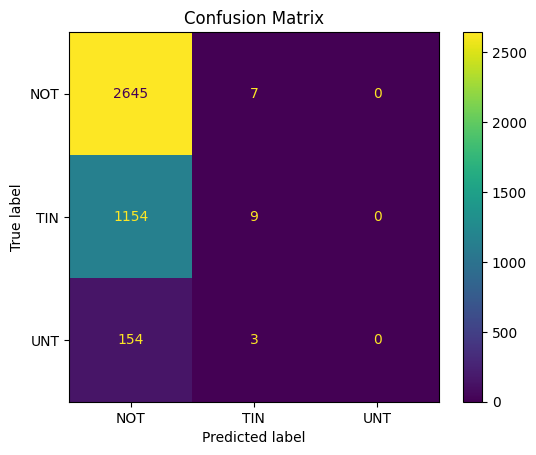

In [ ]:
# Model 3 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(3,3))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m34 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6868
Precision (macro): 0.4554
Recall (macro):    0.3575
F1-score (macro):  0.3177


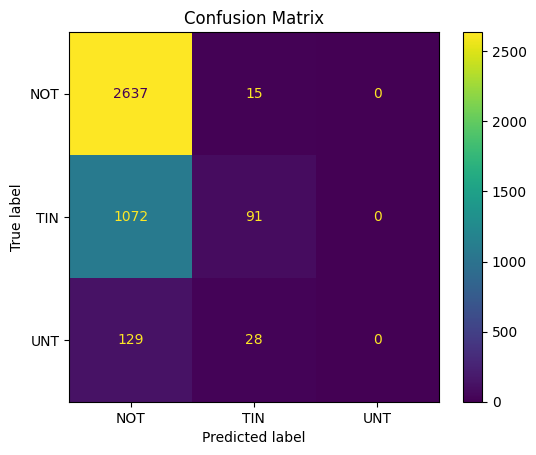

In [ ]:
# Model 4 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m4 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6752
Precision (macro): 0.4611
Recall (macro):    0.3426
F1-score (macro):  0.2872


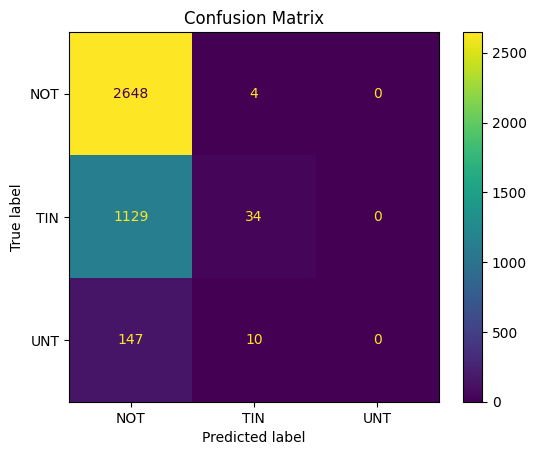

In [ ]:
# Model 4 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,2))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m41 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6712
Precision (macro): 0.4308
Recall (macro):    0.3380
F1-score (macro):  0.2777


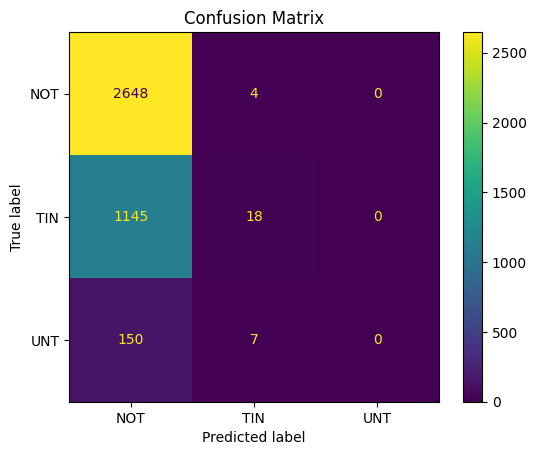

In [ ]:
# Model 4 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(2,2))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m42 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6730
Precision (macro): 0.4466
Recall (macro):    0.3398
F1-score (macro):  0.2814


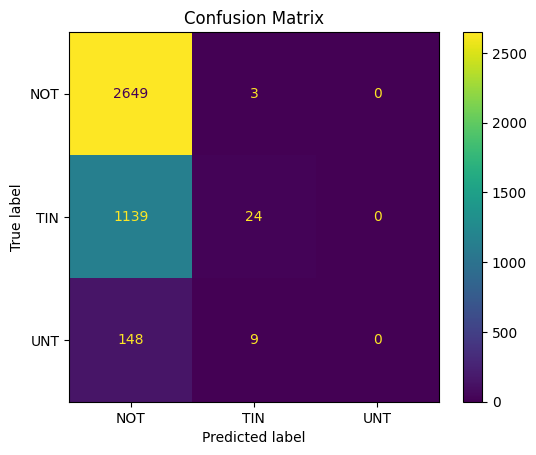

In [ ]:
# Model 4 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,3))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m43 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6684
Precision (macro): 0.3898
Recall (macro):    0.3353
F1-score (macro):  0.2726


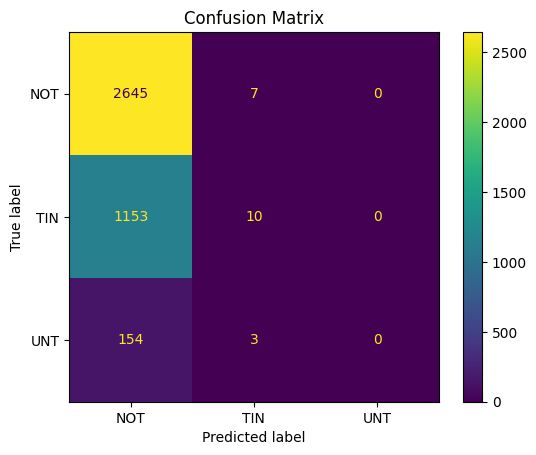

In [ ]:
# Model 4 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(3,3))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m44 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6966
Precision (macro): 0.4636
Recall (macro):    0.3708
F1-score (macro):  0.3422


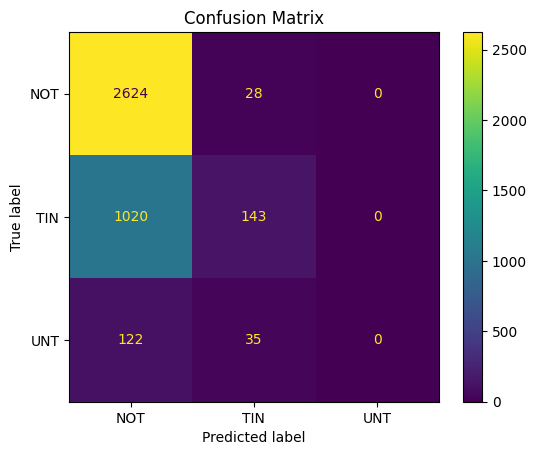

In [ ]:
# Model 5 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m5 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6823
Precision (macro): 0.4673
Recall (macro):    0.3514
F1-score (macro):  0.3054


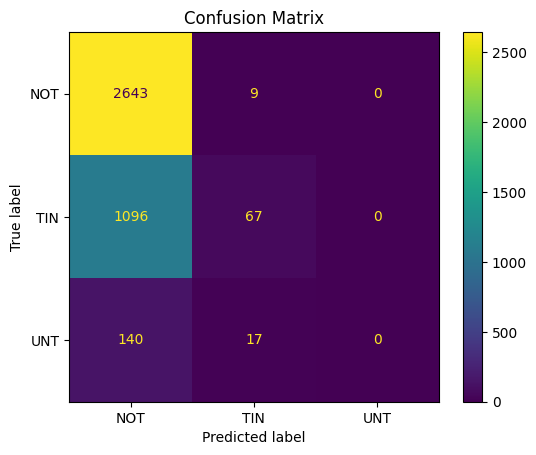

In [ ]:
# Model 5 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,2))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m51 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6694
Precision (macro): 0.4087
Recall (macro):    0.3374
F1-score (macro):  0.2782


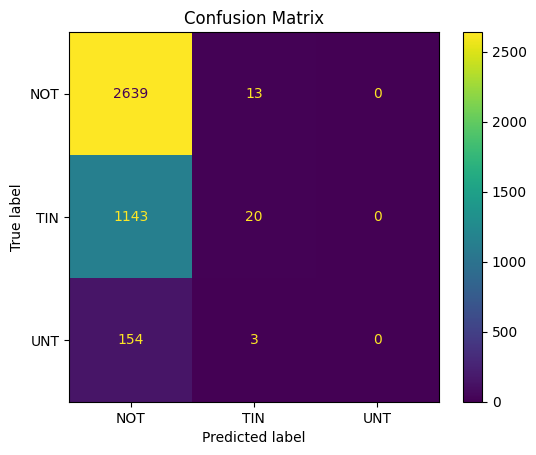

In [ ]:
# Model 5 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(2,2))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m52 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6803
Precision (macro): 0.4700
Recall (macro):    0.3488
F1-score (macro):  0.3000


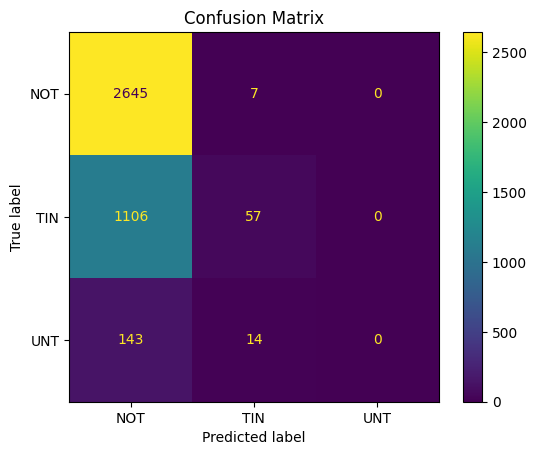

In [ ]:
# Model 5 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,3))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m53 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6672
Precision (macro): 0.3337
Recall (macro):    0.3334
F1-score (macro):  0.2679


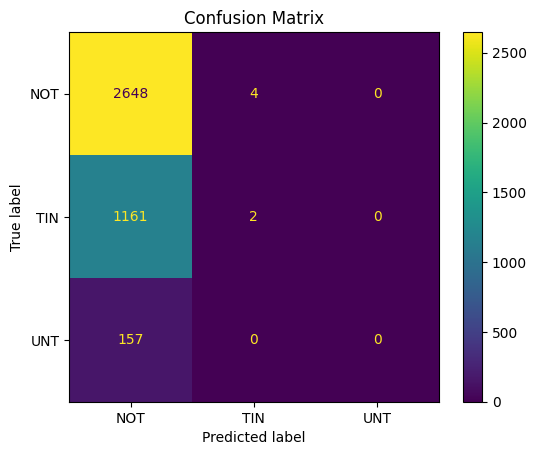

In [ ]:
# Model 5 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(3,3))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m54 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6959
Precision (macro): 0.4660
Recall (macro):    0.3695
F1-score (macro):  0.3397


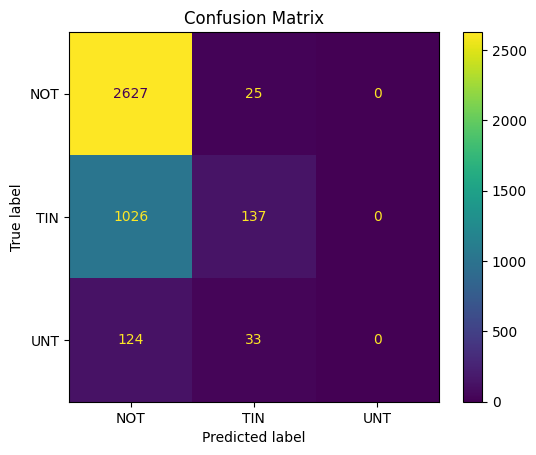

In [ ]:
# Model 6 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m6 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6818
Precision (macro): 0.4703
Recall (macro):    0.3508
F1-score (macro):  0.3042


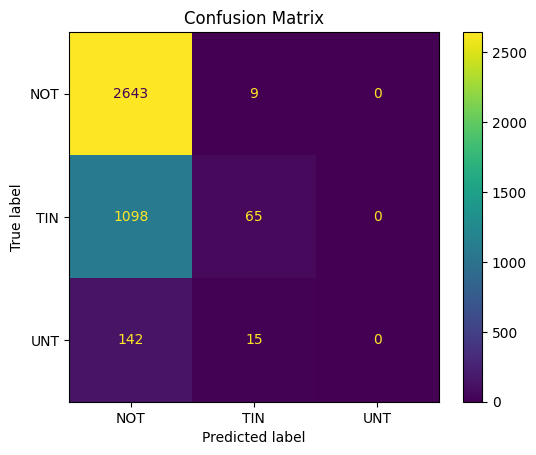

In [ ]:
# Model 6 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,2))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m61 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6712
Precision (macro): 0.4296
Recall (macro):    0.3398
F1-score (macro):  0.2833


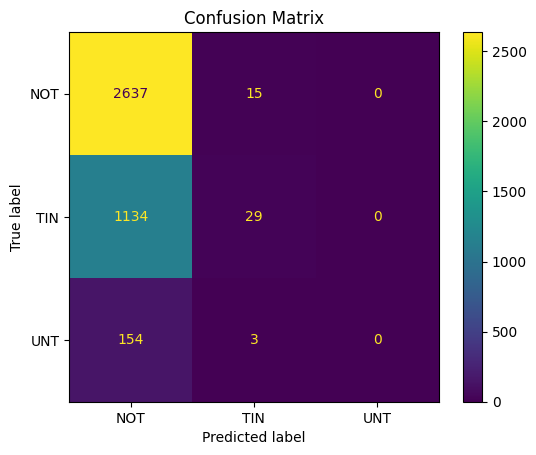

In [ ]:
# Model 6 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(2,2))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m62 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6790
Precision (macro): 0.4630
Recall (macro):    0.3477
F1-score (macro):  0.2981


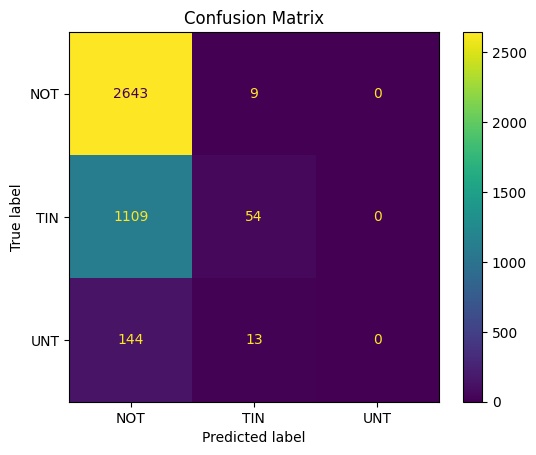

In [ ]:
# Model 6 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,3))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m63 = get_naive_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6672
Precision (macro): 0.3337
Recall (macro):    0.3334
F1-score (macro):  0.2679


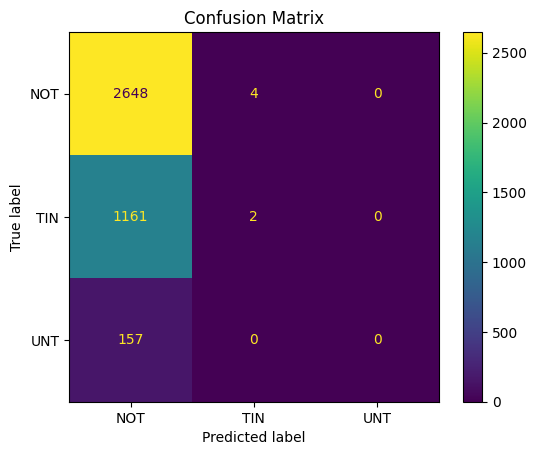

In [ ]:
# Model 6 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(3,3))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m64 = get_naive_predictions(X_train, X_val, y_train, y_val)